# 03 - Error Analysis
Analyze misclassifications and confusion patterns.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)

In [4]:
# Setup paths
PROJECT_ROOT = Path('/home/sjoon/projects/brain_connectivity_classifier')
RESULTS_DIR = PROJECT_ROOT / 'data' / 'results'
ANALYSIS_DIR = PROJECT_ROOT / 'data' / 'analysis'
FIGURES_DIR = PROJECT_ROOT / 'figures' / 'error_analysis'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Results: {RESULTS_DIR}")
print(f"Analysis: {ANALYSIS_DIR}")
print(f"Figures: {FIGURES_DIR}")

Results: /home/sjoon/projects/brain_connectivity_classifier/data/results
Analysis: /home/sjoon/projects/brain_connectivity_classifier/data/analysis
Figures: /home/sjoon/projects/brain_connectivity_classifier/figures/error_analysis


## 1. Load Confusion Matrices

In [5]:
# Load confusion matrices
def load_confusion_matrix(strategy, phase='cv'):
    """Load confusion matrix for given strategy and phase"""
    if phase == 'cv':
        path = RESULTS_DIR / 'full_connectivity_analysis' / strategy / 'confusion_matrix.npy'
    else:  # task
        if strategy == 'multinomial':
            task_dir = 'task_testing'
        else:
            task_dir = f'task_testing_{strategy}'
        path = RESULTS_DIR / 'full_connectivity_analysis' / task_dir / 'task_confusion_matrix.npy'
    
    return np.load(path)

# Load all confusion matrices
cm_cv = {}
cm_task = {}

for strategy in ['multinomial', 'ovo', 'ovr']:
    cm_cv[strategy] = load_confusion_matrix(strategy, 'cv')
    cm_task[strategy] = load_confusion_matrix(strategy, 'task')
    print(f"Loaded {strategy}: CV shape {cm_cv[strategy].shape}, Task shape {cm_task[strategy].shape}")

Loaded multinomial: CV shape (232, 232), Task shape (232, 232)
Loaded ovo: CV shape (232, 232), Task shape (232, 232)
Loaded ovr: CV shape (232, 232), Task shape (232, 232)


In [7]:
# Load network labels
region_info = pd.read_csv(RESULTS_DIR / 'full_connectivity_analysis' / 'multinomial' / 'region_info.csv')
network_labels = region_info['network'].unique()
print(f"\nNumber of networks: {len(network_labels)}")
print(f"Networks: {network_labels}")


Number of networks: 33
Networks: ['VisCent' 'VisPeri' 'SomMotA' 'SomMotB' 'DorsAttnA' 'DorsAttnB'
 'SalVentAttnA' 'SalVentAttnB' 'LimbicB' 'LimbicA' 'ContA' 'ContB' 'ContC'
 'DefaultA' 'DefaultB' 'DefaultC' 'TempPar' 'Hippocampus_ant'
 'Hippocampus_post' 'Amygdala_lat' 'Amygdala_med' 'Thalamus_DP'
 'Thalamus_VP' 'Thalamus_VA' 'Thalamus_DA' 'Accumbens_shell'
 'Accumbens_core' 'Pallidum_post' 'Pallidum_ant' 'Putamen_ant'
 'Putamen_post' 'Caudate_ant' 'Caudate_post']


## 2. Visualize Confusion Matrices

Saved confusion matrices plot


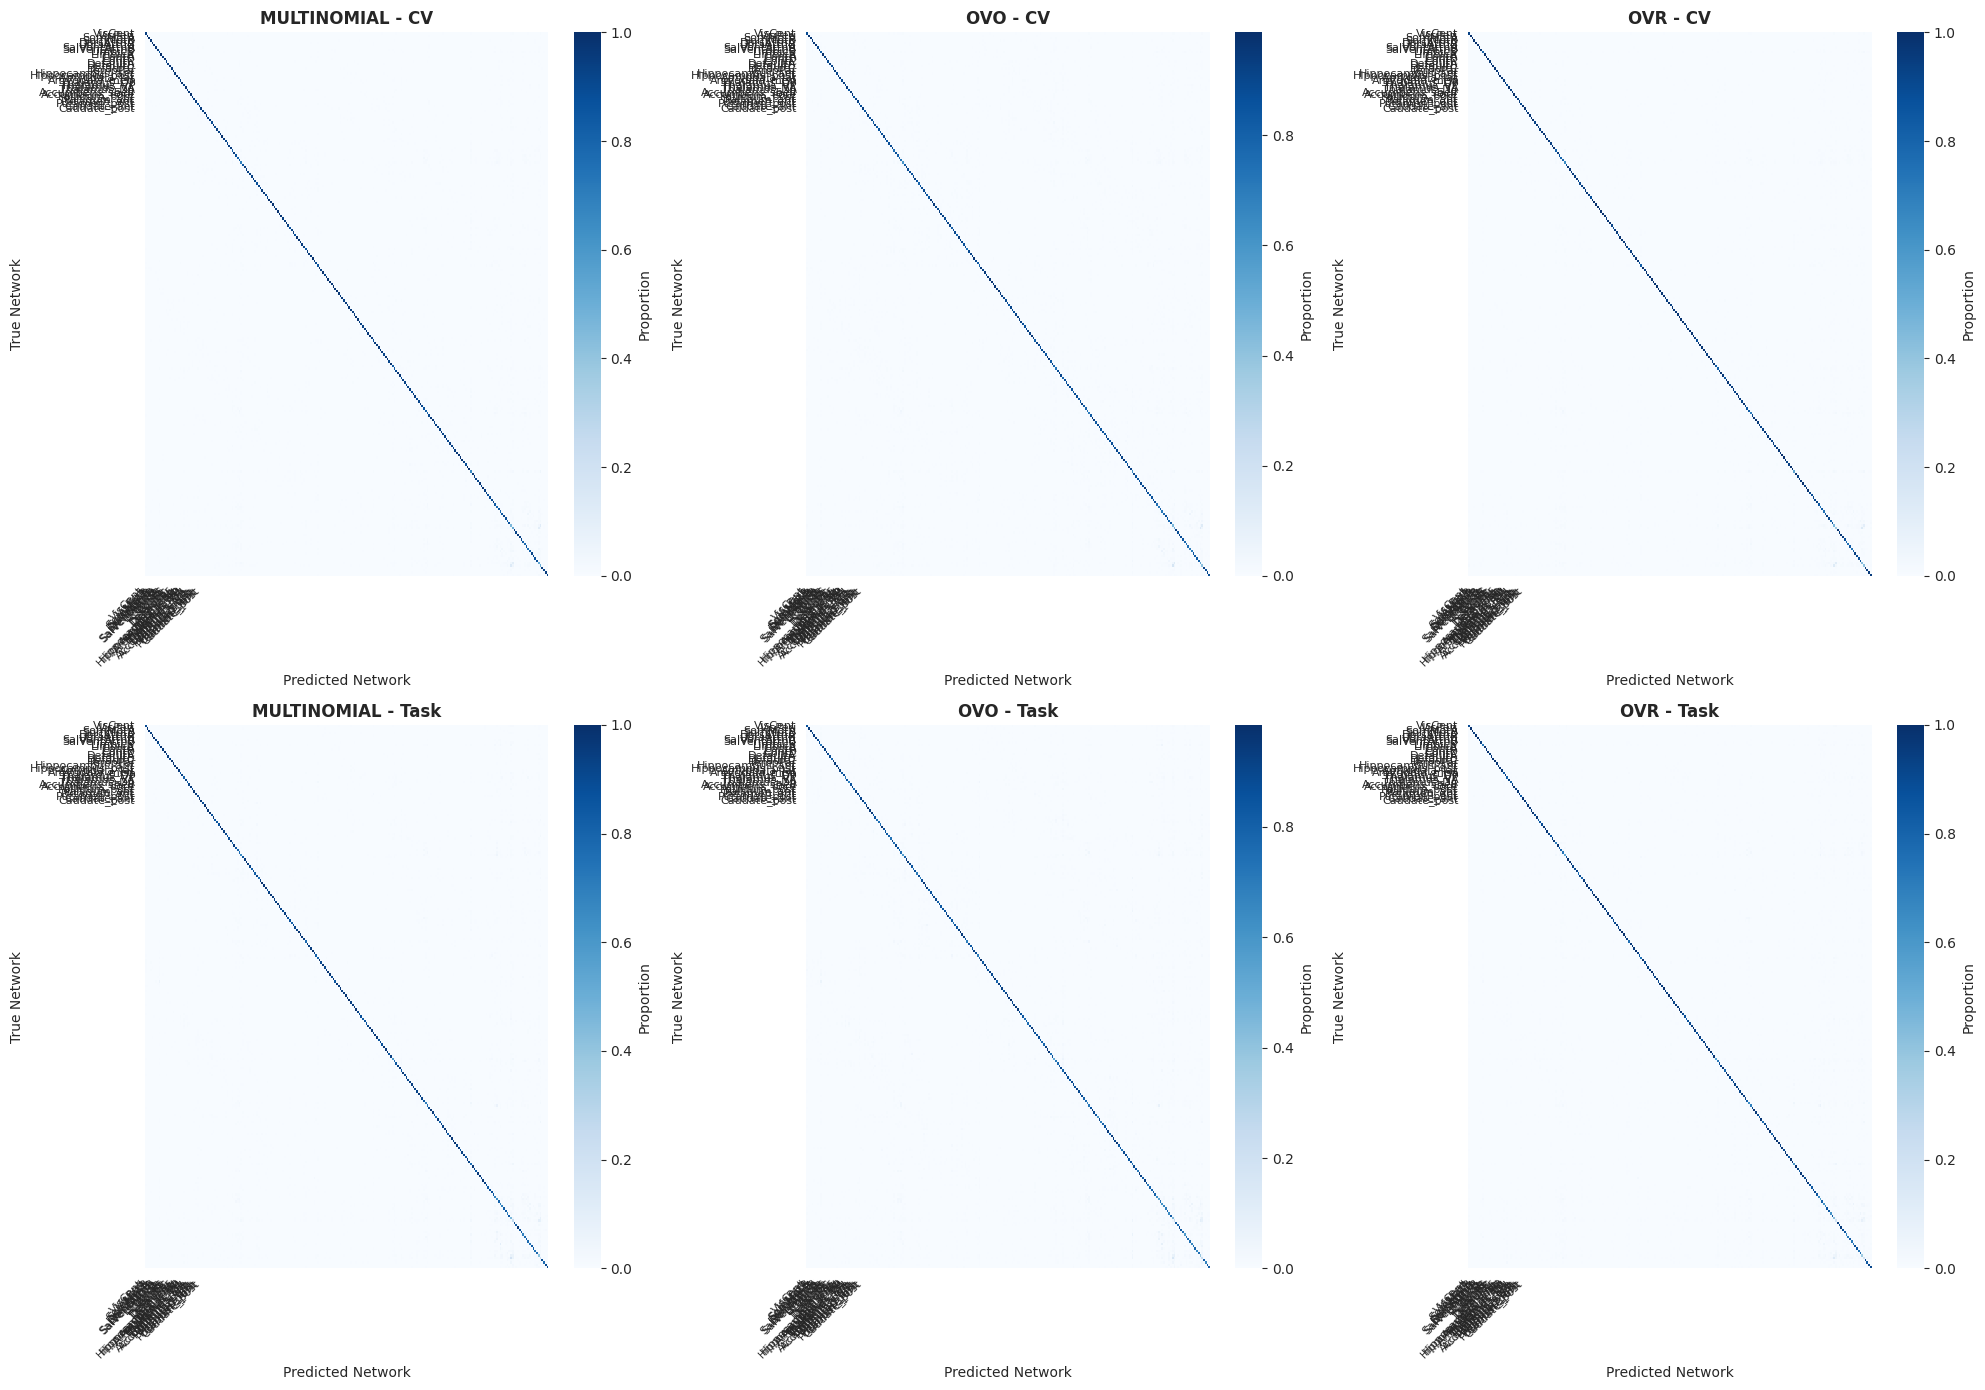

In [8]:
# Plot confusion matrices for all strategies
fig, axes = plt.subplots(2, 3, figsize=(20, 14))

strategies = ['multinomial', 'ovo', 'ovr']
phases = ['CV', 'Task']

for col, strategy in enumerate(strategies):
    for row, phase in enumerate(phases):
        ax = axes[row, col]
        
        # Get confusion matrix
        if phase == 'CV':
            cm = cm_cv[strategy]
        else:
            cm = cm_task[strategy]
        
        # Normalize
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        # Plot
        sns.heatmap(cm_norm, annot=False, fmt='.2f', cmap='Blues', 
                   xticklabels=network_labels, yticklabels=network_labels,
                   ax=ax, cbar_kws={'label': 'Proportion'})
        
        ax.set_title(f'{strategy.upper()} - {phase}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Predicted Network', fontsize=10)
        ax.set_ylabel('True Network', fontsize=10)
        
        # Rotate labels
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrices_all.png', dpi=300, bbox_inches='tight')
print("Saved confusion matrices plot")
plt.show()

## 3. Analyze Misclassification Patterns

In [9]:
# Analyze most common misclassifications
def get_top_misclassifications(cm, labels, n=10):
    """Get top N misclassifications from confusion matrix"""
    misclass = []
    
    for i in range(len(labels)):
        for j in range(len(labels)):
            if i != j:  # Skip diagonal (correct predictions)
                misclass.append({
                    'True': labels[i],
                    'Predicted': labels[j],
                    'Count': int(cm[i, j]),
                    'True_Total': int(cm[i, :].sum())
                })
    
    df = pd.DataFrame(misclass)
    df['Proportion'] = df['Count'] / df['True_Total']
    df = df.sort_values('Count', ascending=False).head(n)
    
    return df

# Get top misclassifications for multinomial strategy
print("Top 15 Misclassifications (CV - Multinomial):")
top_misclass_cv = get_top_misclassifications(cm_cv['multinomial'], network_labels, 15)
print(top_misclass_cv.to_string(index=False))

Top 15 Misclassifications (CV - Multinomial):
           True     Predicted  Count  True_Total  Proportion
   Pallidum_ant  Putamen_post      2         224    0.008929
        LimbicB  SalVentAttnB      2         224    0.008929
          ContA       LimbicB      2         224    0.008929
        VisCent Pallidum_post      1         224    0.004464
   Pallidum_ant       VisCent      1         224    0.004464
      DorsAttnB       LimbicB      1         224    0.004464
    Thalamus_VP  Putamen_post      1         224    0.004464
        VisPeri       VisCent      1         224    0.004464
    Putamen_ant       SomMotB      1         224    0.004464
   Putamen_post       VisCent      1         224    0.004464
       DefaultC Pallidum_post      1         224    0.004464
       DefaultA  Putamen_post      1         224    0.004464
Hippocampus_ant  Amygdala_lat      1         224    0.004464
   SalVentAttnA  Putamen_post      1         224    0.004464
        SomMotB  Pallidum_ant      1   

In [10]:
print("\nTop 15 Misclassifications (Task - Multinomial):")
top_misclass_task = get_top_misclassifications(cm_task['multinomial'], network_labels, 15)
print(top_misclass_task.to_string(index=False))


Top 15 Misclassifications (Task - Multinomial):
           True       Predicted  Count  True_Total  Proportion
          ContA         LimbicB      3         200       0.015
        VisCent    Putamen_post      2         200       0.010
    Thalamus_DA    Amygdala_med      2         200       0.010
    Thalamus_VP     Thalamus_DA      2         200       0.010
       DefaultB Hippocampus_ant      2         200       0.010
   Amygdala_med     Thalamus_VP      2         200       0.010
        LimbicA         LimbicB      2         200       0.010
       DefaultB   Pallidum_post      2         200       0.010
      DorsAttnB     Caudate_ant      1         200       0.005
       DefaultB     Thalamus_DA      1         200       0.005
        SomMotB    SalVentAttnA      1         200       0.005
Hippocampus_ant   Pallidum_post      1         200       0.005
       DefaultA    SalVentAttnB      1         200       0.005
    Putamen_ant       DorsAttnB      1         200       0.005
    Th


Saved top misclassifications plot


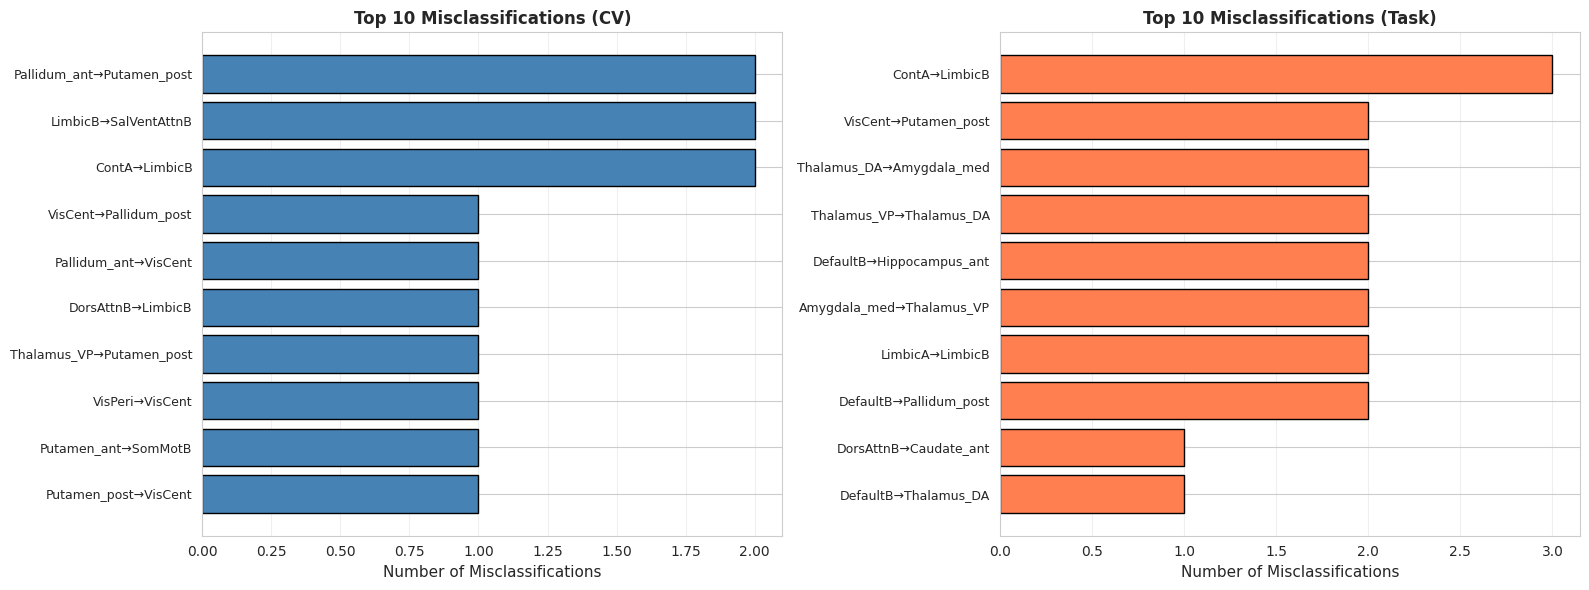

In [11]:
# Plot top misclassifications
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CV misclassifications
ax = axes[0]
top_10_cv = top_misclass_cv.head(10)
labels_cv = [f"{row['True']}→{row['Predicted']}" for _, row in top_10_cv.iterrows()]
ax.barh(range(len(top_10_cv)), top_10_cv['Count'], color='steelblue', edgecolor='black')
ax.set_yticks(range(len(top_10_cv)))
ax.set_yticklabels(labels_cv, fontsize=9)
ax.set_xlabel('Number of Misclassifications', fontsize=11)
ax.set_title('Top 10 Misclassifications (CV)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Task misclassifications
ax = axes[1]
top_10_task = top_misclass_task.head(10)
labels_task = [f"{row['True']}→{row['Predicted']}" for _, row in top_10_task.iterrows()]
ax.barh(range(len(top_10_task)), top_10_task['Count'], color='coral', edgecolor='black')
ax.set_yticks(range(len(top_10_task)))
ax.set_yticklabels(labels_task, fontsize=9)
ax.set_xlabel('Number of Misclassifications', fontsize=11)
ax.set_title('Top 10 Misclassifications (Task)', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'top_misclassifications.png', dpi=300, bbox_inches='tight')
print("\nSaved top misclassifications plot")
plt.show()

## 4. Per-Network Error Analysis

In [12]:
# Calculate per-network error rates
def calculate_network_errors(cm, labels):
    """Calculate error statistics per network"""
    errors = []
    
    for i, label in enumerate(labels):
        total = cm[i, :].sum()
        correct = cm[i, i]
        incorrect = total - correct
        
        errors.append({
            'Network': label,
            'Total': int(total),
            'Correct': int(correct),
            'Incorrect': int(incorrect),
            'Accuracy': correct / total if total > 0 else 0,
            'Error_Rate': incorrect / total if total > 0 else 0
        })
    
    return pd.DataFrame(errors)

# Calculate for CV and Task
network_errors_cv = calculate_network_errors(cm_cv['multinomial'], network_labels)
network_errors_task = calculate_network_errors(cm_task['multinomial'], network_labels)

print("Network Error Rates (CV):")
print(network_errors_cv.sort_values('Error_Rate', ascending=False).to_string(index=False))

Network Error Rates (CV):
         Network  Total  Correct  Incorrect  Accuracy  Error_Rate
         LimbicB    224      190         34  0.848214    0.151786
    Putamen_post    224      198         26  0.883929    0.116071
     Thalamus_VP    224      207         17  0.924107    0.075893
    Amygdala_med    224      210         14  0.937500    0.062500
           ContC    224      210         14  0.937500    0.062500
     Caudate_ant    224      210         14  0.937500    0.062500
         VisCent    224      211         13  0.941964    0.058036
     Thalamus_DA    224      211         13  0.941964    0.058036
        DefaultA    224      212         12  0.946429    0.053571
    Pallidum_ant    224      212         12  0.946429    0.053571
   Pallidum_post    224      213         11  0.950893    0.049107
     Putamen_ant    224      213         11  0.950893    0.049107
    Caudate_post    224      214         10  0.955357    0.044643
        DefaultC    224      215          9  0.959

In [13]:
print("\nNetwork Error Rates (Task):")
print(network_errors_task.sort_values('Error_Rate', ascending=False).to_string(index=False))


Network Error Rates (Task):
         Network  Total  Correct  Incorrect  Accuracy  Error_Rate
         LimbicB    200      155         45     0.775       0.225
     Thalamus_VP    200      162         38     0.810       0.190
     Thalamus_DA    200      162         38     0.810       0.190
    Amygdala_med    200      170         30     0.850       0.150
   Pallidum_post    200      178         22     0.890       0.110
         VisCent    200      179         21     0.895       0.105
    Putamen_post    200      180         20     0.900       0.100
        DefaultB    200      182         18     0.910       0.090
 Accumbens_shell    200      185         15     0.925       0.075
    SalVentAttnB    200      186         14     0.930       0.070
     Thalamus_DP    200      186         14     0.930       0.070
     Thalamus_VA    200      187         13     0.935       0.065
           ContC    200      187         13     0.935       0.065
         SomMotB    200      188         12    


Saved network error rates plot


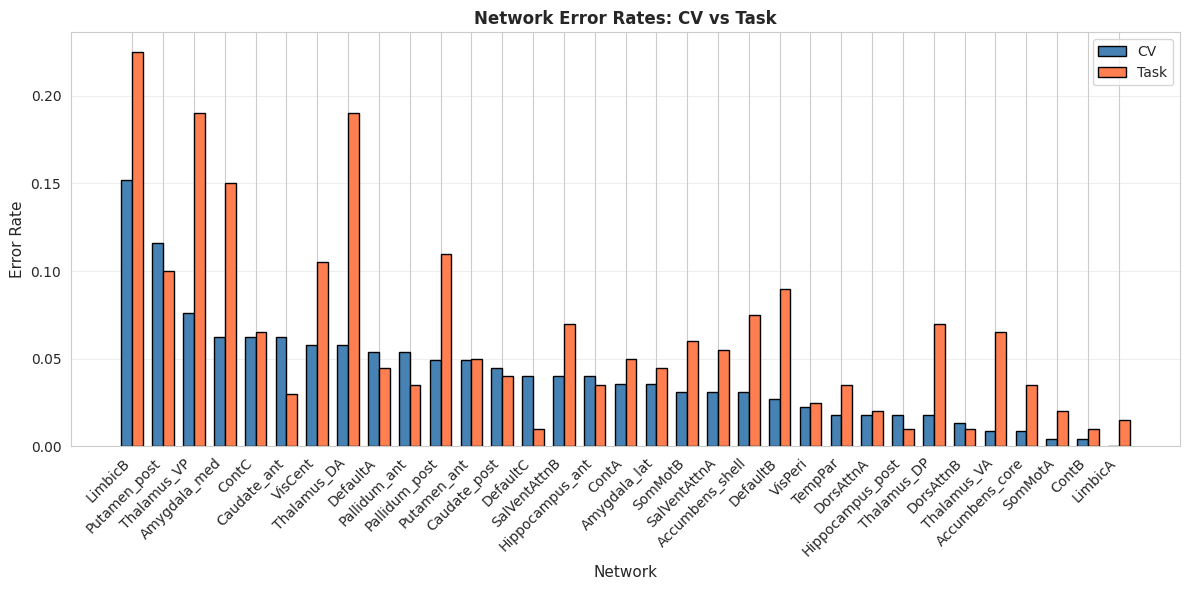

In [14]:
# Plot error rates comparison
fig, ax = plt.subplots(figsize=(12, 6))

# Merge CV and Task data
error_comparison = pd.merge(
    network_errors_cv[['Network', 'Error_Rate']],
    network_errors_task[['Network', 'Error_Rate']],
    on='Network',
    suffixes=('_CV', '_Task')
)

# Sort by CV error rate
error_comparison = error_comparison.sort_values('Error_Rate_CV', ascending=False)

x = np.arange(len(error_comparison))
width = 0.35

ax.bar(x - width/2, error_comparison['Error_Rate_CV'], width, 
       label='CV', color='steelblue', edgecolor='black')
ax.bar(x + width/2, error_comparison['Error_Rate_Task'], width, 
       label='Task', color='coral', edgecolor='black')

ax.set_xlabel('Network', fontsize=11)
ax.set_ylabel('Error Rate', fontsize=11)
ax.set_title('Network Error Rates: CV vs Task', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(error_comparison['Network'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'network_error_rates.png', dpi=300, bbox_inches='tight')
print("\nSaved network error rates plot")
plt.show()

## 5. Confusion Patterns Between Networks

In [15]:
# Identify which networks are most often confused with each other
def get_confusion_pairs(cm, labels):
    """Get network pairs that are frequently confused"""
    pairs = []
    
    for i in range(len(labels)):
        for j in range(i+1, len(labels)):
            # Symmetric confusion
            confusion_ij = cm[i, j]
            confusion_ji = cm[j, i]
            total_confusion = int(confusion_ij + confusion_ji)
            
            if total_confusion > 0:
                pairs.append({
                    'Network_1': labels[i],
                    'Network_2': labels[j],
                    'Confusion_Count': total_confusion,
                    'N1_to_N2': int(confusion_ij),
                    'N2_to_N1': int(confusion_ji)
                })
    
    return pd.DataFrame(pairs).sort_values('Confusion_Count', ascending=False)

# Get confusion pairs
confusion_pairs_cv = get_confusion_pairs(cm_cv['multinomial'], network_labels)
confusion_pairs_task = get_confusion_pairs(cm_task['multinomial'], network_labels)

print("Top 15 Confused Network Pairs (CV):")
print(confusion_pairs_cv.head(15).to_string(index=False))

Top 15 Confused Network Pairs (CV):
   Network_1     Network_2  Confusion_Count  N1_to_N2  N2_to_N1
SalVentAttnB       LimbicB                3         1         2
     LimbicB  Putamen_post                2         1         1
     LimbicB         ContA                2         0         2
     LimbicB Pallidum_post                2         1         1
Pallidum_ant  Putamen_post                2         2         0
    DefaultA  Amygdala_lat                2         1         1
     VisPeri       LimbicB                1         1         0
     VisCent  Pallidum_ant                1         0         1
     VisCent Pallidum_post                1         1         0
     VisCent       VisPeri                1         0         1
     VisCent  Putamen_post                1         0         1
     VisPeri Pallidum_post                1         1         0
     SomMotB  SalVentAttnB                1         0         1
SalVentAttnA   Caudate_ant                1         0         1
SalV

In [16]:
print("\nTop 15 Confused Network Pairs (Task):")
print(confusion_pairs_task.head(15).to_string(index=False))


Top 15 Confused Network Pairs (Task):
   Network_1       Network_2  Confusion_Count  N1_to_N2  N2_to_N1
     LimbicB           ContA                4         1         3
     VisCent    Putamen_post                3         2         1
Amygdala_med     Thalamus_VP                3         2         1
Amygdala_med     Thalamus_DA                3         1         2
     LimbicB         LimbicA                2         0         2
    DefaultB Hippocampus_ant                2         2         0
    DefaultB   Pallidum_post                2         2         0
 Thalamus_VP     Thalamus_DA                2         2         0
     SomMotA    SalVentAttnA                1         1         0
     VisCent       DorsAttnA                1         0         1
     VisCent         LimbicB                1         1         0
     VisCent     Thalamus_DA                1         1         0
   DorsAttnB     Caudate_ant                1         1         0
   DorsAttnB     Putamen_ant         

In [17]:
# Save error analysis results
top_misclass_cv.to_csv(ANALYSIS_DIR / 'top_misclassifications_cv.csv', index=False)
top_misclass_task.to_csv(ANALYSIS_DIR / 'top_misclassifications_task.csv', index=False)
network_errors_cv.to_csv(ANALYSIS_DIR / 'network_errors_cv.csv', index=False)
network_errors_task.to_csv(ANALYSIS_DIR / 'network_errors_task.csv', index=False)
confusion_pairs_cv.to_csv(ANALYSIS_DIR / 'confusion_pairs_cv.csv', index=False)
confusion_pairs_task.to_csv(ANALYSIS_DIR / 'confusion_pairs_task.csv', index=False)

print("\n" + "="*80)
print("ERROR ANALYSIS COMPLETE")
print("="*80)
print("\nSaved files:")
print("  - top_misclassifications_cv.csv")
print("  - top_misclassifications_task.csv")
print("  - network_errors_cv.csv")
print("  - network_errors_task.csv")
print("  - confusion_pairs_cv.csv")
print("  - confusion_pairs_task.csv")
print("\nSaved figures:")
print("  - confusion_matrices_all.png")
print("  - top_misclassifications.png")
print("  - network_error_rates.png")


ERROR ANALYSIS COMPLETE

Saved files:
  - top_misclassifications_cv.csv
  - top_misclassifications_task.csv
  - network_errors_cv.csv
  - network_errors_task.csv
  - confusion_pairs_cv.csv
  - confusion_pairs_task.csv

Saved figures:
  - confusion_matrices_all.png
  - top_misclassifications.png
  - network_error_rates.png
